In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df_healthcare = pd.read_csv("/content/healthcare_eda_dataset (1).csv")

In [11]:
clinical_summary = df_healthcare[["Age", "BMI", "Cholesterol", "Disease_Risk_Score"]].describe()
print(clinical_summary)

             Age         BMI  Cholesterol  Disease_Risk_Score
count  250.00000  250.000000   250.000000          250.000000
mean    50.42000   26.813600   256.872000           51.534800
std     20.17662    4.821952    36.429715           12.793464
min     18.00000   11.900000   164.000000           18.900000
25%     33.00000   23.700000   228.250000           41.050000
50%     50.00000   26.600000   255.000000           52.150000
75%     69.00000   30.400000   286.000000           60.450000
max     84.00000   41.300000   344.000000           83.000000


In [12]:
correlation_matrix = df_healthcare[[
    "Age", "BMI", "Cholesterol", "Glucose", "Exercise_Hours_Per_Week", "Disease_Risk_Score"
]].corr()
print("--- Clinical Metrics Correlation Matrix ---")
print(correlation_matrix)

--- Clinical Metrics Correlation Matrix ---
                              Age       BMI  Cholesterol   Glucose  \
Age                      1.000000  0.040006     0.750109  0.067957   
BMI                      0.040006  1.000000     0.313319  0.423070   
Cholesterol              0.750109  0.313319     1.000000  0.193627   
Glucose                  0.067957  0.423070     0.193627  1.000000   
Exercise_Hours_Per_Week -0.049590  0.011361    -0.080012 -0.028300   
Disease_Risk_Score       0.682078  0.276206     0.651560  0.275322   

                         Exercise_Hours_Per_Week  Disease_Risk_Score  
Age                                    -0.049590            0.682078  
BMI                                     0.011361            0.276206  
Cholesterol                            -0.080012            0.651560  
Glucose                                -0.028300            0.275322  
Exercise_Hours_Per_Week                 1.000000           -0.241321  
Disease_Risk_Score                     

In [13]:
x = np.linspace(0,10,100)
print(x)

[ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.97979798  8.08080808  8.18181818  8

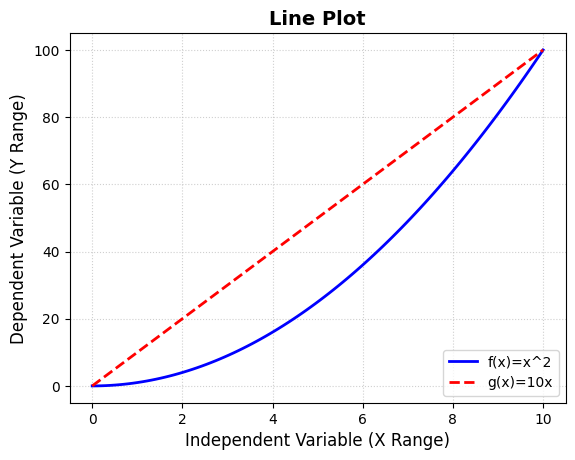

In [32]:
y1 = x**2 # Quadratic Growth Function: f(x) = x^2
y2 = 10*x # Linear baseline growth: g(x) = 10x

plt.plot(x,y1,label="f(x)=x^2", color= "blue", linestyle="-", linewidth=2)
plt.plot(x,y2,label="g(x)=10x", color= "red", linestyle="--", linewidth=2)

plt.title("Line Plot", fontsize=14, fontweight="bold")
plt.xlabel("Independent Variable (X Range)", fontsize=12)
plt.ylabel("Dependent Variable (Y Range)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("line_plot_functions.png",bbox_inches="tight")
# plt.close()

In [33]:
df_election = pd.read_csv("/content/election_data.csv")
df_district = pd.read_csv("/content/district_data (1).csv")
df_province = pd.read_csv("/content/province_data.csv")

In [37]:
df_master=pd.merge(
    df_election,
    df_district,
    on="district_id",
    how="inner"
    ).merge(df_province,
           on="province_id",
            how="left"
            )

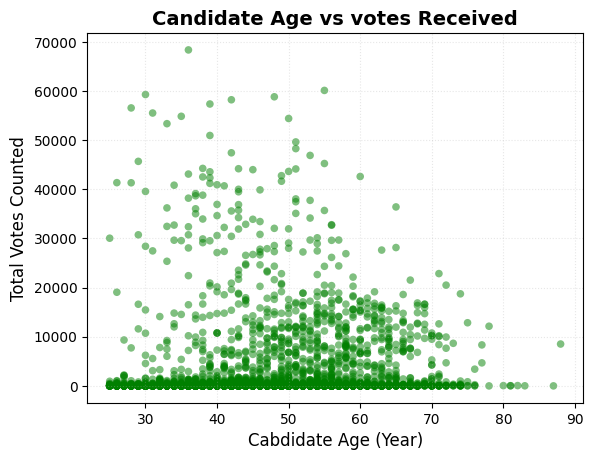

In [56]:
plt.scatter(df_master["age"],df_master["votes"],color="green",alpha=0.5, edgecolors="none", s=30)
plt.title("Candidate Age vs votes Received", fontsize=14, fontweight="bold")
plt.xlabel("Cabdidate Age (Year)", fontsize=12)
plt.ylabel("Total Votes Counted", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.3)
plt.savefig("Candidate_age_vs_vote_scatter.png",bbox_inches="tight")

In [59]:
party_counts = df_master["party"].value_counts().head(5).sort_values(ascending=True)
party_counts

,count
party,
CPN (Unified Marxist-Leninist),164
Rastriya Swatantra Party,164
Communist Party of Nepal,164
Nepali Congress,165
Independent,1143


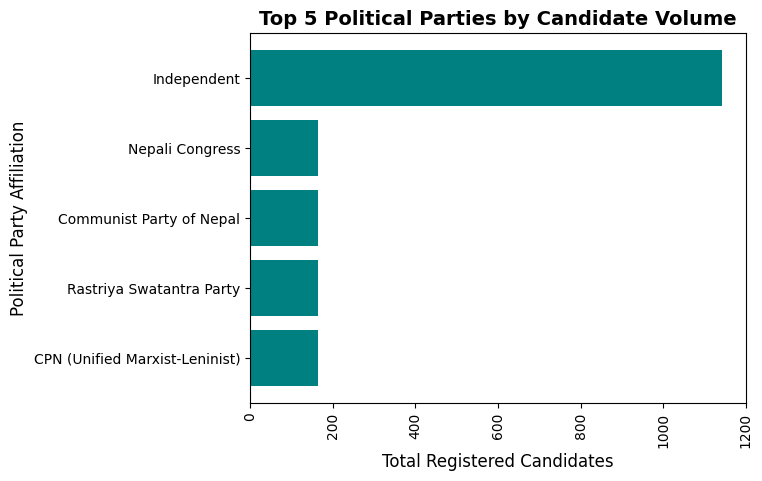

In [73]:
plt.barh(party_counts.index,party_counts.values, color="teal")
plt.title("Top 5 Political Parties by Candidate Volume", fontsize=14, fontweight="bold")
plt.xlabel("Total Registered Candidates", fontsize=12)
plt.xticks(rotation="vertical")
plt.ylabel("Political Party Affiliation", fontsize=12)
plt.savefig("top_parties_chart.png", bbox_inches="tight")

In [75]:
gender_distribution = df_master["gender"].value_counts()
gender_distribution

,count
gender,
male,3017
female,388
other,1


Text(0.5, 1.0, 'Candidate Gender Representation Share')

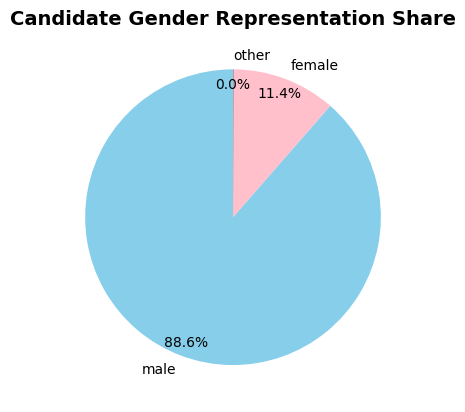

In [89]:
plt.pie(
    gender_distribution.values,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    colors = ["skyblue","pink","black"],
    startangle=90,
    pctdistance=0.9
)
plt.title("Candidate Gender Representation Share", fontsize=14, fontweight="bold")

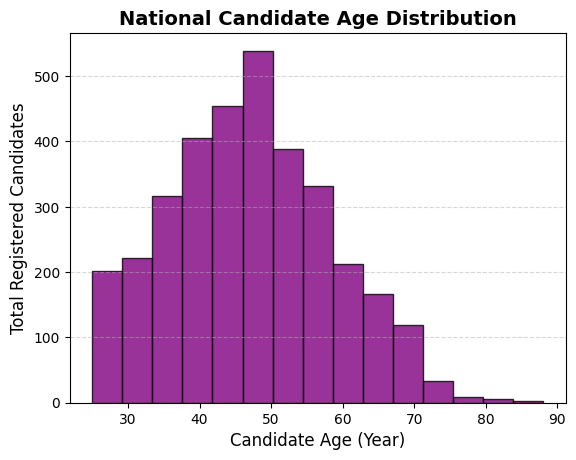

In [96]:
plt.hist(df_master["age"],bins=15, color="purple",edgecolor="black",alpha=0.8)
plt.title("National Candidate Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Candidate Age (Year)", fontsize=12)
plt.ylabel("Total Registered Candidates", fontsize=12)
plt.grid(True,axis="y", linestyle="--", alpha=0.5)
plt.savefig("candidate_age_histogram.png", bbox_inches="tight")

In [99]:
province_order = df_master.groupby("province_name")["age"].median().sort_values().index
print(province_order)

Index(['Madhesh', 'Bagmati', 'Sudurpashchim', 'Koshi', 'Lumbini', 'Gandaki',
       'Karnali'],
      dtype='object', name='province_name')


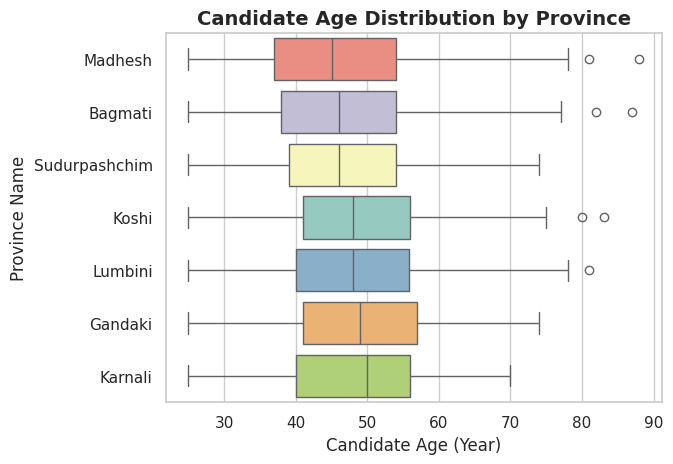

In [104]:
import seaborn as sns
sns.set_theme(style="whitegrid")
sns.boxplot(
    data=df_master,
    x="age",
    y="province_name",
    hue="province_name",
    order=province_order,
    palette="Set3"
)
plt.title("Candidate Age Distribution by Province", fontsize=14, fontweight="bold")
plt.xlabel("Candidate Age (Year)", fontsize=12)
plt.ylabel("Province Name", fontsize=12)
plt.show()